In [1]:
# Lumped Capacitor Example from Femwell, 

In [2]:
from IPython.display import display, Math

eq1 = r"C = \frac{2W}{(\Delta V)^2}"
eq2 = r"W = \frac{1}{2} \int_{\Omega} \epsilon \mathbf{E} \cdot \mathbf{E} d\Omega"

display(Math(eq1))
display(Math(eq2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import shapely
from meshwell.model import Model
from meshwell.polysurface import PolySurface
from skfem import Basis, ElementDG, ElementTriP0, Functional
from skfem.helpers import dot
from skfem.io.meshio import from_meshio

from femwell.coulomb import solve_coulomb
from femwell.visualization import plot_domains, plot_subdomain_boundaries

RuntimeError: no validator found for <class 'shapely.geometry.polygon.Polygon'>, see `arbitrary_types_allowed` in Config

In [4]:
# Define some parameters for the capacitor:

dielectric_epsilon = 16
separation = 4
metal_thickness = 1
delta_voltage = 1

In [5]:
def parallel_plate_capacitor_mesh(
    width,
    separation=separation,
    thickness=metal_thickness,
):
    top_plate_polygon = shapely.geometry.box(
        -width / 2, separation / 2, width / 2, separation / 2 + thickness
    )
    bottom_plate_polygon = shapely.geometry.box(
        -width / 2, -separation / 2 - thickness, width / 2, -separation / 2
    )
    dielectric_polygon = shapely.geometry.box(
        -width / 2, -separation / 2, width / 2, separation / 2
    )

    capacitor_polygon = shapely.unary_union(
        [top_plate_polygon, bottom_plate_polygon, dielectric_polygon]
    )
    air_polygon = capacitor_polygon.buffer(20, resolution=8)

    model = Model()

    top_plate = PolySurface(
        polygons=top_plate_polygon,
        model=model,
        physical_name="top_plate",
        mesh_bool=False,
        resolution={"resolution": 0.5, "DistMax": 2},
        mesh_order=1,
    )
    bottom_plate = PolySurface(
        polygons=bottom_plate_polygon,
        model=model,
        physical_name="bottom_plate",
        mesh_bool=False,
        resolution={"resolution": 0.5, "DistMax": 2},
        mesh_order=2,
    )
    dielectric = PolySurface(
        polygons=dielectric_polygon,
        model=model,
        physical_name="dielectric",
        mesh_bool=True,
        mesh_order=3,
    )
    air = PolySurface(
        polygons=air_polygon,
        model=model,
        physical_name="air",
        mesh_bool=True,
        mesh_order=4,
    )

    return from_meshio(
        model.mesh(
            entities_list=[top_plate, bottom_plate, dielectric, air],
            filename="mesh.msh",
            default_characteristic_length=0.5,
        )
    )


mesh = parallel_plate_capacitor_mesh(
    width=2,
    separation=separation,
    thickness=metal_thickness,
)
mesh.draw().show()

plot_domains(mesh)
plt.show()

plot_subdomain_boundaries(mesh)

NameError: name 'PolySurface' is not defined

In [6]:
def potential(mesh, dV=delta_voltage, dielectric_epsilon=16):
    basis_epsilon = Basis(mesh, ElementTriP0())
    epsilon = basis_epsilon.ones()

    epsilon[basis_epsilon.get_dofs(elements=("dielectric"))] = dielectric_epsilon

    basis_u, u = solve_coulomb(
        basis_epsilon,
        epsilon,
        {
            "top_plate___dielectric": dV,
            "top_plate___air": dV,
            "bottom_plate___dielectric": 0,
            "bottom_plate___air": 0,
        },
    )

    return basis_u, u, basis_epsilon, epsilon


basis_u, u, basis_epsilon, epsilon = potential(mesh, dV=delta_voltage)

NameError: name 'mesh' is not defined

In [7]:
def potential(mesh, dV=delta_voltage, dielectric_epsilon=16):
    basis_epsilon = Basis(mesh, ElementTriP0())
    epsilon = basis_epsilon.ones()

    epsilon[basis_epsilon.get_dofs(elements=("dielectric"))] = dielectric_epsilon

    basis_u, u = solve_coulomb(
        basis_epsilon,
        epsilon,
        {
            "top_plate___dielectric": dV,
            "top_plate___air": dV,
            "bottom_plate___dielectric": 0,
            "bottom_plate___air": 0,
        },
    )

    return basis_u, u, basis_epsilon, epsilon


basis_u, u, basis_epsilon, epsilon = potential(mesh, dV=delta_voltage)

NameError: name 'mesh' is not defined

NameError: name 'basis_epsilon' is not defined

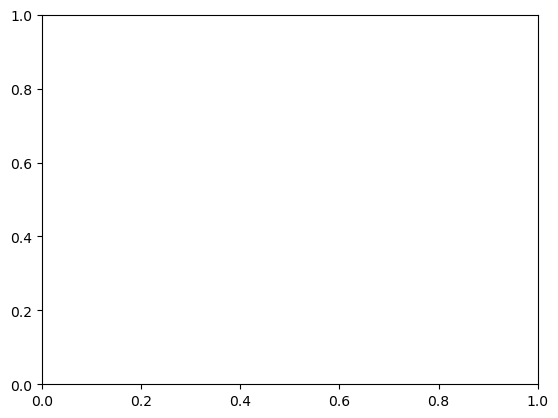

In [8]:
fig, ax = plt.subplots()
for subdomain in basis_epsilon.mesh.subdomains.keys() - {"gmsh:bounding_entities"}:
    basis_epsilon.mesh.restrict(subdomain).draw(ax=ax, boundaries_only=True)
basis_u.plot(u, ax=ax, shading="gouraud", colorbar=True)
# basis_vec.plot(-u_grad, ax=ax)
plt.show()

In [9]:
for subdomain in basis_epsilon.mesh.subdomains.keys() - {"gmsh:bounding_entities"}:
    basis_epsilon.mesh.restrict(subdomain).draw(ax=ax, boundaries_only=True)
basis_grad = basis_u.with_element(ElementDG(basis_u.elem))

fig, ax = plt.subplots()
e_x = basis_u.project(-basis_epsilon.interpolate(epsilon) * basis_u.interpolate(u).grad[0])
basis_u.plot(e_x, ax=ax, shading="gouraud", colorbar=True)
plt.show()

fig, ax = plt.subplots()
e_y = basis_u.project(-basis_epsilon.interpolate(epsilon) * basis_u.interpolate(u).grad[1])
basis_u.plot(e_y, ax=ax, shading="gouraud", colorbar=True)
plt.show()

NameError: name 'basis_epsilon' is not defined

In [10]:
def capacitance(
    width=2,
    separation=separation,
    thickness=metal_thickness,
    dV=delta_voltage,
    dielectric_epsilon=dielectric_epsilon,
):
    mesh = parallel_plate_capacitor_mesh(
        width=width,
        separation=separation,
        thickness=thickness,
    )
    basis_u, u, basis_epsilon, epsilon = potential(
        mesh, dV=dV, dielectric_epsilon=dielectric_epsilon
    )

    @Functional(dtype=complex)
    def W(w):
        return 0.5 * w["epsilon"] * dot(w["u"].grad, w["u"].grad)

    C = (
        2
        * W.assemble(
            basis_u,
            epsilon=basis_epsilon.interpolate(epsilon),
            u=basis_u.interpolate(u),
        )
        / dV**2
    )

    return C

In [11]:
import tqdm

widths = np.linspace(1, 50, 21)
Cs_dict = {}
for dielectric_epsilon in [1, 3.9, 16]:
    Cs = []
    for width in tqdm.tqdm(widths):
        Cs.append(
            capacitance(
                width=width,
                separation=separation,
                thickness=metal_thickness,
                dV=delta_voltage,
                dielectric_epsilon=dielectric_epsilon,
            )
        )
    Cs_dict[dielectric_epsilon] = Cs

  0%|          | 0/21 [00:00<?, ?it/s]


NameError: name 'PolySurface' is not defined

In [12]:
colors = ["tab:blue", "tab:orange", "tab:green"]

for dielectric_epsilon, color in zip([1, 3.9, 16], colors):
    plt.plot(
        widths,
        np.array(Cs_dict[dielectric_epsilon]),
        color=color,
        linestyle="-",
        label=dielectric_epsilon,
    )
    plt.plot(
        widths, np.array(widths) * dielectric_epsilon / separation, color=color, linestyle="--"
    )
    plt.xlabel("Width / a.u.")
    plt.ylabel(r"Capacitance per unit length / $\epsilon_0$ / a.u.")

plt.legend(title="Dielectric")
plt.show()

KeyError: 1

In [13]:
colors = ["tab:blue", "tab:orange", "tab:green"]

for dielectric_epsilon, color in zip([1, 3.9, 16], colors):
    reference = np.array(widths) * dielectric_epsilon / separation

    plt.plot(
        widths,
        np.array(Cs_dict[dielectric_epsilon]) / reference,
        color=color,
        linestyle="-",
        label=dielectric_epsilon,
    )
    plt.xlabel("Width / a.u.")
    plt.ylabel(r"Relative error in capacitance per unit length / $\epsilon_0$ / a.u.")

plt.legend(title="Dielectric")
plt.show()

KeyError: 1